In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, exposure
from best_frame_fix import *
from app_helper import render_flm_frame, norm, get_tile_flm_bbox_with_pad
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import torch
from model_setup import load_sam2_model, load_lightglue_models, load_swinir_model, estimate_transform, apply_transform_overlay, create_tensor_from_mask, get_keypoint_matches, swinir_upscale, load_sam2_auto_model
import ipywidgets as widgets
from lightglue import viz2d


ROOT_DIR = Path(r"C:\Users\sar31\Documents\GitHub\flm_tem_alignment")
DEFAULT_DIR = ROOT_DIR / "jey_002_g3_l3"
flm_path =  DEFAULT_DIR / "Composite-stacks-JEY002-G3-L3.tif"
tem_path = DEFAULT_DIR / "JEY002_G3_L3_1950x_t-13.tif"
flm_pixel_nm = 121.0
tem_pixel_nm = 6.9
pad_factor = 1

In [2]:
flm_stack = io.imread(str(flm_path))
tem_img = io.imread(str(tem_path))
tem_h, tem_w = tem_img.shape[:2]
flm_h, flm_w = flm_stack.shape[1:3]
tem_height_flm = (tem_h * tem_pixel_nm) / flm_pixel_nm
tem_width_flm  = (tem_w * tem_pixel_nm) / flm_pixel_nm

# convert uint16 to unint 8
rendered_stack = render_all_frames(flm_stack, render_flm_frame)

In [3]:
# for each flm frame in the stack find the bounding boxes, do merging and cleaning
# and then again merge them across the stack to find get global set of bounding boxes
# then uses these bounding boxes for cropping
# find the laplacian on these bboxes

# otku threshold to segment the fluorescent regions
roi_masks = [get_roi_mask(flm_stack[i]) for i in range(len(flm_stack))]

# get the bounding boxes from these masks
bboxes = [get_bbox_from_roi_mask(roi_mask) for roi_mask in roi_masks]

# filter and merge the bounding boxes
filted_and_merged_bboxes = [filter_and_merge_bboxes(b, tem_height_flm / 2, tem_width_flm / 2, flm_h, flm_w) for b in bboxes]

# now do a remerging across all the bounding boxes to get a set of global bounding boxes
all_bboxes = []
for b in filted_and_merged_bboxes:
    all_bboxes.extend(b)
global_bboxes = filter_and_merge_bboxes(all_bboxes, tem_height_flm / 2, tem_width_flm / 2, flm_h, flm_w)

# now do the cropping across the stack for each bbox and then figure out the best frame for that bounding box 

In [4]:
laps_per_bbox = get_laplacian_per_bbox(flm_stack, global_bboxes)

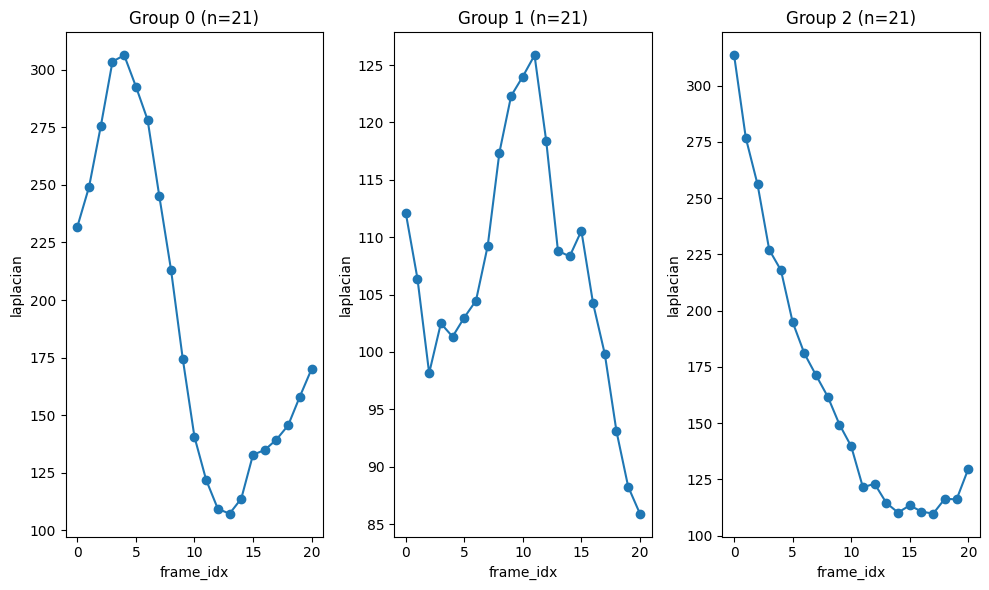

In [5]:
# plot of laplacian across the frames for different groups/bboxes
plot_groups_laplacian(groups_vals=laps_per_bbox)

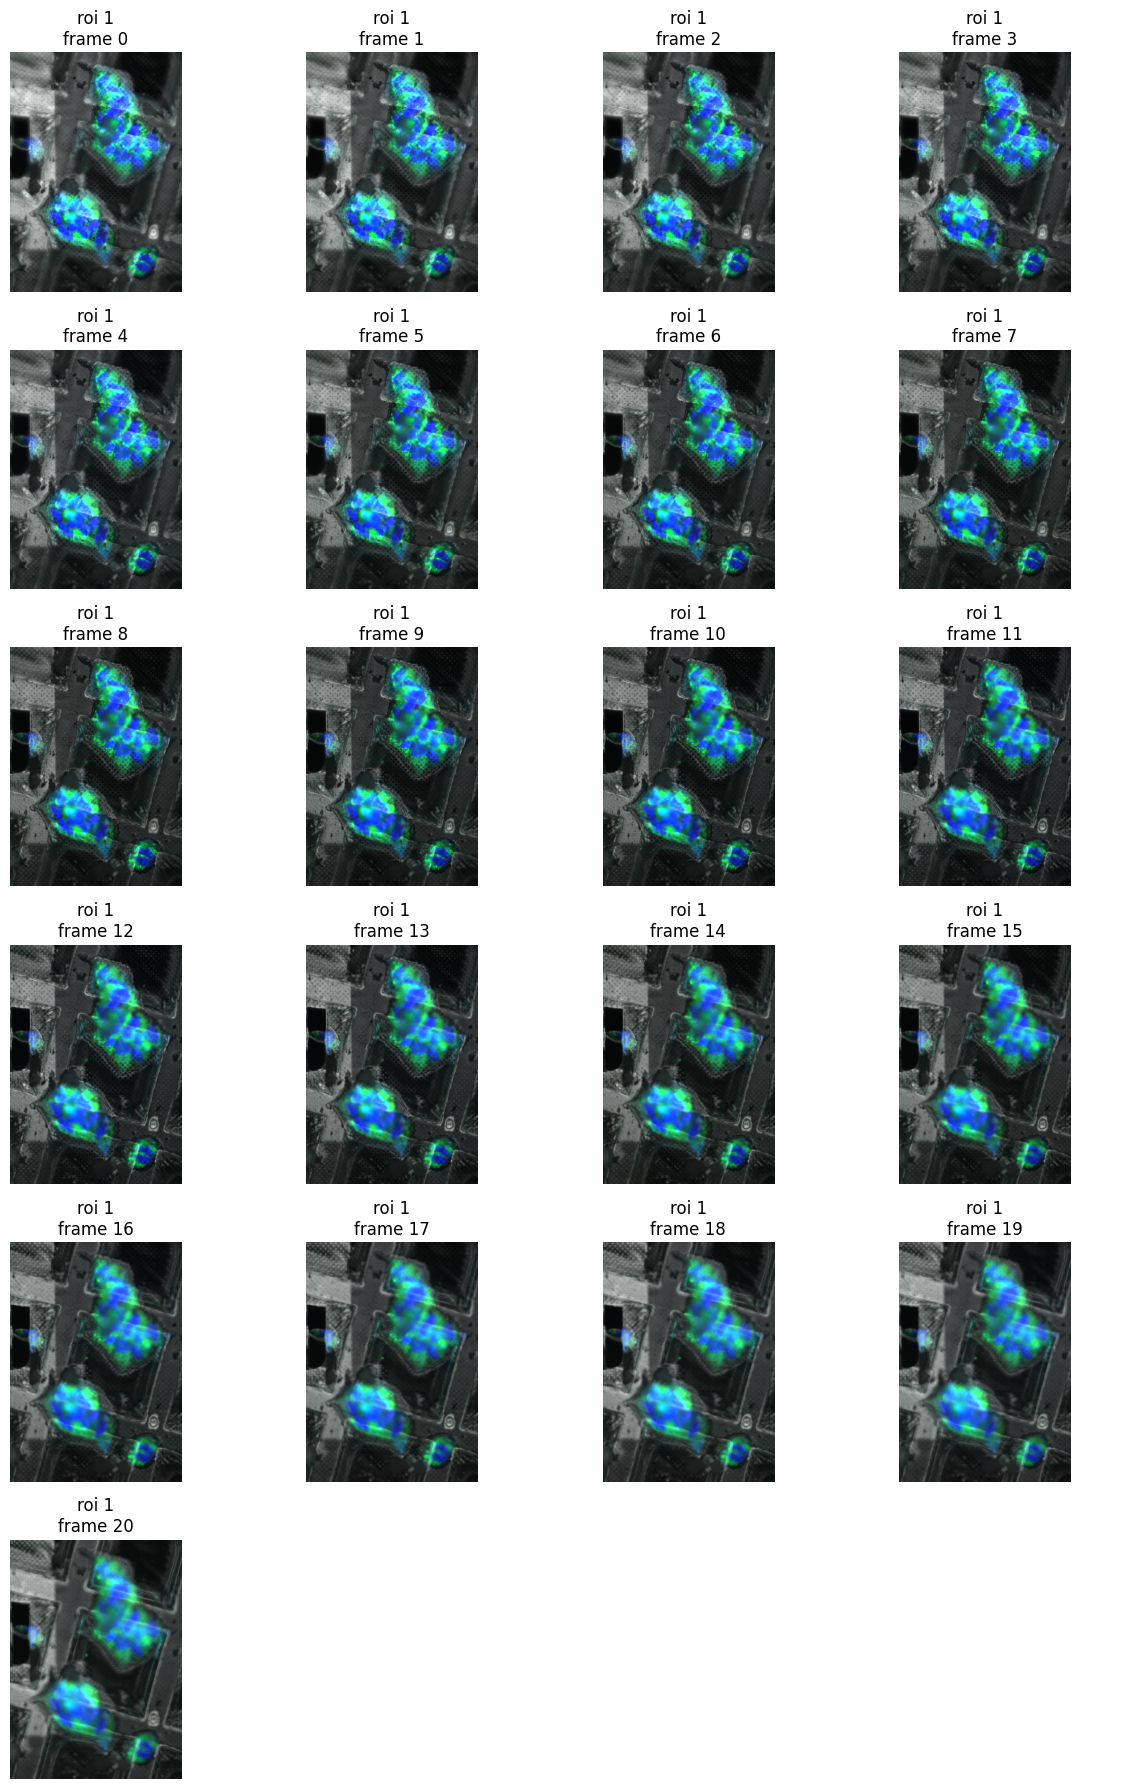

In [9]:
roi_idx = 1
bbox = global_bboxes[roi_idx]
rendered_stack = np.array(rendered_stack)
crops = []
for i in range(len(rendered_stack)):
    y0, x0, y1, x1 = bbox
    crops.append((roi_idx, i, rendered_stack[i, y0:y1, x0:x1]))
plot_group_crops(crops)

In [10]:
bbox_best_frame = []
for bbox_idx, laps in enumerate(laps_per_bbox):
    peak_idx, peak_vals = find_flat_peak(laps)
    if peak_idx:
        bbox_best_frame.append({"bbox_idx": bbox_idx, "frame_idx": peak_idx})
        print(f"BBox: {bbox_idx} -> Best Frame: {peak_idx}, Val: {peak_vals[peak_idx]}")
    else:
        print(f"BBox: {bbox_idx} -> No peak found")

BBox: 0 -> Best Frame: 4, Val: 281.69124798834224
BBox: 1 -> Best Frame: 10, Val: 119.23914462268469
BBox: 2 -> No peak found


In [56]:
tiles_and_frame = tiles_per_best_frame(bbox_best_frame)

In [ ]:
# next step is to crop directly from the equalize image and to save it somewhere
crops = []
for tf in tiles_and_frame:
    best_frame_idx = tf["frame_idx"]
    flm_frame = flm_stack[best_frame_idx, :, :, 1] # use refl channel
    flm_frame_eq = equalize_flm_frame(flm_frame)
    flm_frame_eq_rgb = np.stack([flm_frame_eq] * 3, axis=-1)
    for bbox in tf["bboxes"]:
        y0, x0, y1, x1 = bbox # this has already been in the frame of image
        best_roi_cropped = flm_frame_eq_rgb[y0:y1, x0:x1]
        crops.append(best_roi_cropped)

In [60]:
# next step to upsample everything
swinir_model = load_swinir_model()
upscaled = swinir_upscale( # upscaled is a list
    swinir_model,
    crops,
)

c:\Users\sar31\Documents\GitHub\flm_tem_alignment\.venv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\sar31\Documents\GitHub\flm_tem_alignment\.venv\lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ SwinIR loaded from 002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth


In [62]:
# next step threshold at 150
tiles_upsampled_thresholded = []
thresh = 150
for img in upscaled:
    img_t = (img > thresh).astype(np.uint8) * 255
    tiles_upsampled_thresholded.append(img_t)

In [2]:
sam2_model = load_sam2_auto_model()

SAM2 Automatic mask generator loaded from sam2.1_hiera_small.pt


In [16]:
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2_model,
    points_per_side=32,
    points_per_batch=16,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
)

In [9]:
img_u8, thresh_img = prepare_tem(tem_img)

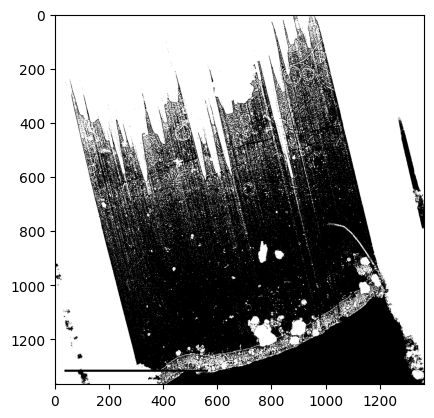

In [10]:
plt.imshow(thresh_img, cmap='gray')

In [11]:
masks = mask_generator_2.generate(thresh_img)

In [12]:
small = cv2.resize(thresh_img, dsize=None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

In [17]:
masks_small = mask_generator_2.generate(small)

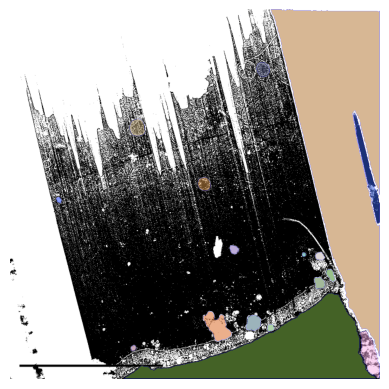

In [18]:
plt.imshow(small)
show_anns(masks_small)
plt.axis('off')
plt.show() 